This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).


In [7]:
%pip install -U "ml_dtypes>=0.5" jax[cuda12] tensorflow keras keras-hub

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 36.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 110.0 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 101.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 MB 101.9 MB/s  0:00:020:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [nvidia-nvshmem-cu12]idia-nvshmem-cu12]2]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [8]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Text generation

### A brief history of sequence generation

### Training a mini-GPT

In [2]:
import os

# Free up more GPU memory on the Jax and TensorFlow backends.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

In [3]:
import keras
import pathlib

extract_dir = keras.utils.get_file(
    fname="mini-c4",
    origin=(
        "https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"
    ),
    extract=True,
)
extract_dir = pathlib.Path(extract_dir) / "mini-c4"

In [4]:
with open(extract_dir / "shard0.txt", "r") as f:
    print(f.readline().replace("\\n", "\n")[:100])

Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You


In [5]:
import keras_hub
import numpy as np

vocabulary_file = keras.utils.get_file(
    origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",
)
tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

2026-06-13 21:45:01.193696: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1781387101.195201    3965 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:47:00.0, compute capability: 8.0
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


In [6]:
tokenizer.tokenize("The quick brown fox.")

E0613 21:45:02.250006    3965 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 79.25GiB (85097971712 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Array([  450,  4996, 17354,  1701, 29916, 29889], dtype=int32)

In [7]:
tokenizer.detokenize([450, 4996, 17354, 1701, 29916, 29889])

'The quick brown fox.'

In [8]:
import tensorflow as tf

batch_size = 64
sequence_length = 256
suffix = np.array([tokenizer.token_to_id("<|endoftext|>")])

def read_file(filename):
    ds = tf.data.TextLineDataset(filename)
    ds = ds.map(lambda x: tf.strings.regex_replace(x, r"\\n", "\n"))
    ds = ds.map(tokenizer, num_parallel_calls=8)
    return ds.map(lambda x: tf.concat([x, suffix], -1))

files = [str(file) for file in extract_dir.glob("*.txt")]
ds = tf.data.Dataset.from_tensor_slices(files)
ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
ds = ds.rebatch(sequence_length + 1, drop_remainder=True)
ds = ds.map(lambda x: (x[:-1], x[1:]))
ds = ds.batch(batch_size).prefetch(8)

In [9]:
num_batches = 58746
num_val_batches = 500
num_train_batches = num_batches - num_val_batches
val_ds = ds.take(num_val_batches).repeat()
train_ds = ds.skip(num_val_batches).repeat()

#### Building the model

In [10]:
from keras import layers

class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads):
        super().__init__()
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(
            num_heads, key_dim, dropout=0.1
        )
        self.self_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()
        self.dropout = layers.Dropout(0.1)

    def call(self, inputs):
        residual = x = inputs
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = self.dropout(x)
        x = x + residual
        x = self.self_attention_layernorm(x)
        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = self.dropout(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x

In [11]:
from keras import ops

class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim):
        super().__init__()
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs, reverse=False):
        if reverse:
            token_embeddings = self.token_embeddings.embeddings
            return ops.matmul(inputs, ops.transpose(token_embeddings))
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [12]:
keras.config.set_dtype_policy("mixed_float16")

vocab_size = tokenizer.vocabulary_size()
hidden_dim = 512
intermediate_dim = 2056
num_heads = 8
num_layers = 8

inputs = keras.Input(shape=(None,), dtype="int32", name="inputs")
embedding = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)
x = embedding(inputs)
x = layers.LayerNormalization()(x)
for i in range(num_layers):
    x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(x)
outputs = embedding(x, reverse=True)
mini_gpt = keras.Model(inputs, outputs)

#### Pretraining the model

In [13]:
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self):
        self.rate = 2e-4
        self.warmup_steps = 1_000.0

    def __call__(self, step):
        step = ops.cast(step, dtype="float32")
        scale = ops.minimum(step / self.warmup_steps, 1.0)
        return self.rate * scale

In [15]:
%pip install matplotlib

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 16.7 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 12.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


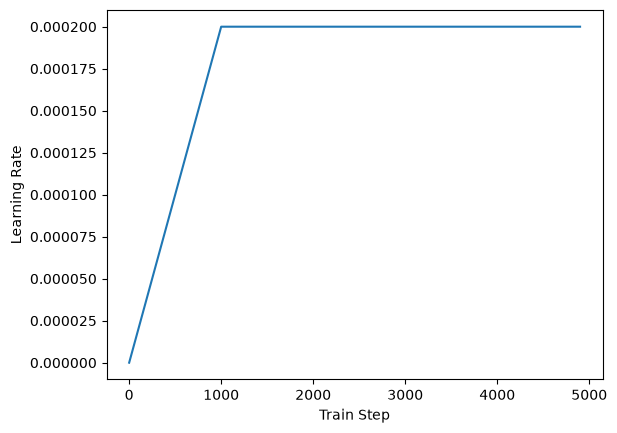

In [16]:
import matplotlib.pyplot as plt

schedule = WarmupSchedule()
x = range(0, 5_000, 100)
y = [ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x, y)
plt.xlabel("Train Step")
plt.ylabel("Learning Rate")
plt.show()

In [ ]:
# ⚠️NOTE⚠️: If you can run the following with a Colab Pro GPU, we suggest you
# do so. This fit() call will take many hours on free tier GPUs. You can also
# reduce steps_per_epoch to try the code with a less trained model.

In [17]:
num_epochs = 8
steps_per_epoch = num_train_batches // num_epochs
validation_steps = num_val_batches

mini_gpt.compile(
    optimizer=keras.optimizers.Adam(schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
mini_gpt.fit(
    train_ds,
    validation_data=val_ds,
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
)

Epoch 1/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 450s 54ms/step - accuracy: 0.2217 - loss: 5.1866 - val_accuracy: 0.2902 - val_loss: 4.3288
Epoch 2/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 380s 52ms/step - accuracy: 0.3006 - loss: 4.2348 - val_accuracy: 0.3251 - val_loss: 4.0093
Epoch 3/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 379s 52ms/step - accuracy: 0.3207 - loss: 4.0337 - val_accuracy: 0.3368 - val_loss: 3.8831
Epoch 4/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 381s 52ms/step - accuracy: 0.3301 - loss: 3.9353 - val_accuracy: 0.3447 - val_loss: 3.8031
Epoch 5/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 380s 52ms/step - accuracy: 0.3369 - loss: 3.8669 - val_accuracy: 0.3493 - val_loss: 3.7497
Epoch 6/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 381s 52ms/step - accuracy: 0.3411 - loss: 3.8237 - val_accuracy: 0.3545 - val_loss: 3.7049
Epoch 7/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 381s 52ms/step - accuracy: 0.3452 - loss: 3.7831 - val_accuracy: 0.3560 - val_loss: 3.6788
Epoch 8/8
7280/7280 ━━━━━━━━━━━━━━━━━━━━ 380s 52ms/step - accuracy: 0.3469 -

#### Generative decoding

In [ ]:
def generate(prompt, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    for _ in range(max_length - prompt_length):
        prediction = mini_gpt(ops.convert_to_numpy([tokens]))
        prediction = ops.convert_to_numpy(prediction[0, -1])
        tokens.append(np.argmax(prediction).item())
    return tokenizer.detokenize(tokens)

In [18]:
prompt = "A piece of advice"
generate(prompt)

NameError: name 'generate' is not defined

In [19]:
def compiled_generate(prompt, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        tokens[i] = np.argmax(prediction).item()
    return tokenizer.detokenize(tokens)

In [20]:
import timeit
tries = 10
timeit.timeit(lambda: compiled_generate(prompt), number=tries) / tries

0.8555514924228191

In [21]:
compiled_generate(prompt)

'A piece of advice from the owner of the website.\nThe website is a website that is designed to provide a user-friendly and user-friendly website. It is designed to provide a user-friendly website that is easy to use and is easy to use.\nThe website is designed to provide a'

#### Sampling strategies

In [22]:
def compiled_generate(prompt, sample_fn, max_length=64):
    tokens = list(ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(tokens)
    tokens = tokens + [0] * (max_length - prompt_length)
    for i in range(prompt_length, max_length):
        prediction = mini_gpt.predict(np.array([tokens]), verbose=0)
        prediction = prediction[0, i - 1]
        next_token = ops.convert_to_numpy(sample_fn(prediction))
        tokens[i] = np.array(next_token).item()
    return tokenizer.detokenize(tokens)

In [23]:
def greedy_search(preds):
    return ops.argmax(preds)

compiled_generate(prompt, greedy_search)

'A piece of advice from the owner of the website.\nThe website is a website that is designed to provide a user-friendly and user-friendly website. It is designed to provide a user-friendly website that is easy to use and is easy to use.\nThe website is designed to provide a'

In [24]:
def random_sample(preds, temperature=1.0):
    preds = preds / temperature
    return keras.random.categorical(preds[None, :], num_samples=1)[0]

In [25]:
compiled_generate(prompt, random_sample)

'A piece of advice from a personal and professional on VTDC VTDC Trustee.\nQC, on VTDC Trustee; VTDC Trustee; VTDC Trustee; VTDC Trustee; VTDC Trustee; VTDC Trustee; VTDC Trust'

In [26]:
from functools import partial
compiled_generate(prompt, partial(random_sample, temperature=2.0))

'A piece of advice about and improving ownership will boost/proof applicability and thus incorporate higher standard bank training following construction and educational prizidards or programs into construction mode.) Vineote can demand user interface on servers. Mobile Infrash Sippinal leverten great database even where loan leasing'

In [27]:
compiled_generate(prompt, partial(random_sample, temperature=0.8))

'A piece of advice; but it was more than enough to teach me about the issue and the importance of building a better life.\nThis entry was posted in HR, Social Media, Hospitality, Community, Social Media, PhD, Nurses. Bookmark the permalink. ⁇  Tracy Mc'

In [28]:
compiled_generate(prompt, partial(random_sample, temperature=0.2))

'A piece of advice from the author.\nThe author of the book is a member of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the Society of the'

In [29]:
def top_k(preds, k=5, temperature=1.0):
    preds = preds / temperature
    top_preds, top_indices = ops.top_k(preds, k=k, sorted=False)
    choice = keras.random.categorical(top_preds[None, :], num_samples=1)[0]
    return ops.take_along_axis(top_indices, choice, axis=-1)

In [30]:
compiled_generate(prompt, partial(top_k, k=5))

'A piece of advice on how to get a better understanding of the topic of this topic in a short while.\nA few years ago, I had to write down a few of my thoughts on what I wanted to do to get the best results from my blog posts. The first thing I wanted to do was to write'

In [31]:
compiled_generate(prompt, partial(top_k, k=20))

'A piece of advice that will help you get a clear picture of how you could get your business to grow!\nSoft, lightweight and easy to build and a solid foundation. I can help you to stay focused on your future. Let us know where we are coming from, and we’ll try to find'

In [32]:
compiled_generate(prompt, partial(top_k, k=5, temperature=0.5))

'A piece of advice.\nI’m a bit of a fan of the blog. I’ve always been a fan of the blog and I’m always looking for a new blogger. I’ve been a fan of the blog and I have been blogging for a while now. I have been writing'